In [158]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor as VIF
from statsmodels.stats.anova import anova_lm
from ISLP import load_data
from ISLP.models import (ModelSpec as MS, summarize, poly)
import seaborn as sns

In [159]:
df = pd.read_csv("../data/insurance (1).csv")

In [160]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1340 entries, 0 to 1339
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1340 non-null   int64  
 1   age            1335 non-null   float64
 2   gender         1340 non-null   object 
 3   bmi            1340 non-null   float64
 4   bloodpressure  1340 non-null   int64  
 5   diabetic       1340 non-null   object 
 6   children       1340 non-null   int64  
 7   smoker         1340 non-null   object 
 8   region         1337 non-null   object 
 9   claim          1340 non-null   float64
dtypes: float64(3), int64(3), object(4)
memory usage: 104.8+ KB


In [161]:
df.shape

(1340, 10)

In [162]:
pd.set_option("display.float_format", "{:2f}".format)

In [163]:
sns.set(style = "whitegrid", palette="Set2", font_scale=1.1)

In [164]:
df.duplicated().sum()

np.int64(0)

In [165]:
df.isna().sum()

Id               0
age              5
gender           0
bmi              0
bloodpressure    0
diabetic         0
children         0
smoker           0
region           3
claim            0
dtype: int64

In [166]:
df.dropna(inplace=True)
df.shape

(1332, 10)

In [167]:
df.describe(include='all')

,Id,age,gender,bmi,bloodpressure,diabetic,children,smoker,region,claim
count,1332.000000,1332.000000,1332,1332.000000,1332.000000,1332,1332.000000,1332,1332,1332.000000
unique,NaN,NaN,2,NaN,NaN,2,NaN,2,4,NaN
top,NaN,NaN,male,NaN,NaN,No,NaN,No,southeast,NaN
freq,NaN,NaN,670,NaN,NaN,695,NaN,1058,442,NaN
mean,674.474474,38.086336,NaN,30.658333,94.189189,NaN,1.099850,NaN,NaN,13325.246426
std,384.703785,11.112804,NaN,6.118967,11.445173,NaN,1.205958,NaN,NaN,12109.620712
min,1.000000,18.000000,NaN,16.000000,80.000000,NaN,0.000000,NaN,NaN,1121.870000
25%,341.750000,29.000000,NaN,26.200000,86.000000,NaN,0.000000,NaN,NaN,4760.157500
50%,674.500000,38.000000,NaN,30.350000,92.000000,NaN,1.000000,NaN,NaN,9412.965000
75%,1007.250000,47.000000,NaN,34.725000,99.000000,NaN,2.000000,NaN,NaN,16781.327500


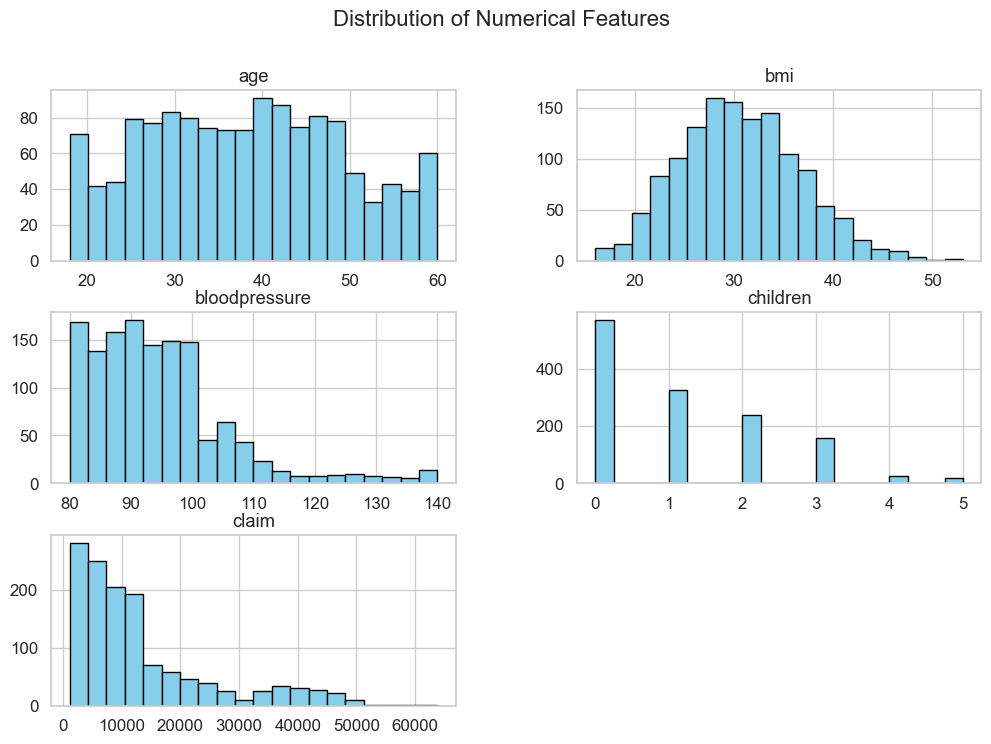

In [168]:
numeric_cols=['age', 'bmi', 'bloodpressure', 'children', 'claim']
df[numeric_cols].hist(bins=20, figsize=(12,8), color='skyblue', edgecolor='black')
plt.suptitle('Distribution of Numerical Features', fontsize=16)
plt.show()

/var/folders/gx/3hdn2trj407cfml5pfq8jd9m0000gn/T/ipykernel_59834/4178876006.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, palette='Set2')
/var/folders/gx/3hdn2trj407cfml5pfq8jd9m0000gn/T/ipykernel_59834/4178876006.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, palette='Set2')
/var/folders/gx/3hdn2trj407cfml5pfq8jd9m0000gn/T/ipykernel_59834/4178876006.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, palette='Set2')
/var/folders/gx/3hdn2trj407cfml5pfq8jd9m0000gn/T/ipykernel_59

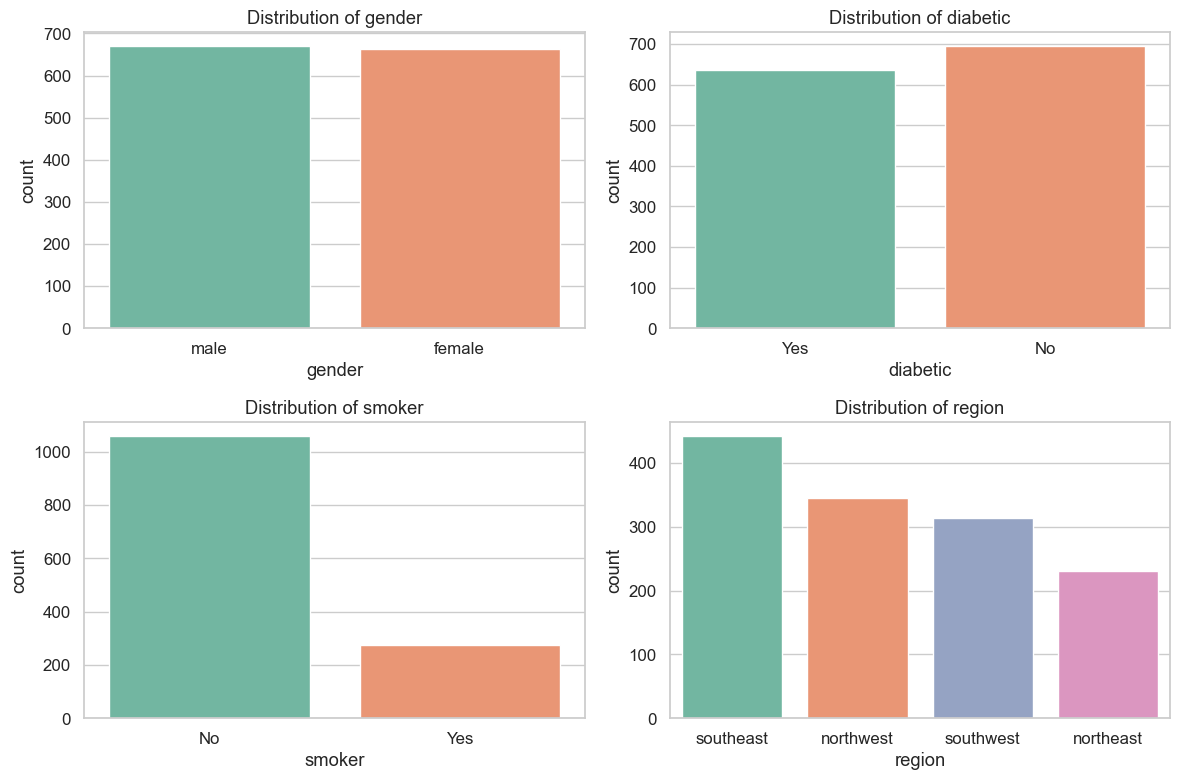

In [169]:
cat_cols=['gender', 'diabetic', 'smoker', 'region']
plt.figure(figsize=(12,8))

for i, col in enumerate(cat_cols, 1):
    plt.subplot(2,2,i)
    sns.countplot(data=df, x=col, palette='Set2')
    plt.title(f"Distribution of {col}")

plt.tight_layout()
plt.show()


In [170]:
df.groupby(['gender', 'smoker'])['claim'].mean().round(2)

gender  smoker
female  No        8762.300000
        Yes      30679.000000
male    No        8169.250000
        Yes      33042.010000
Name: claim, dtype: float64

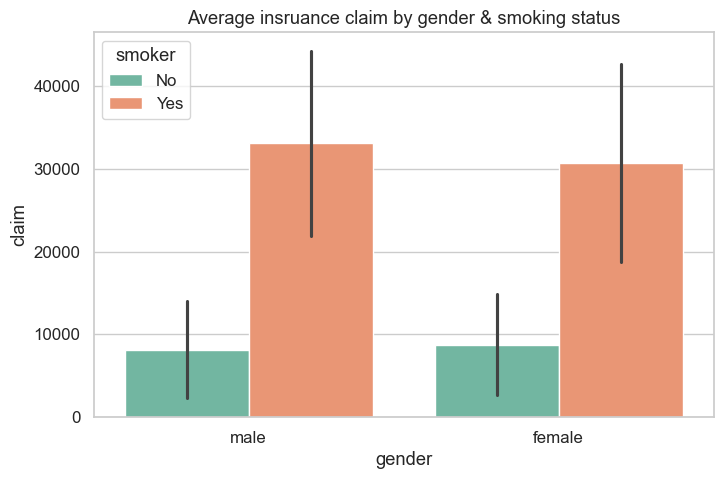

In [171]:
plt.figure(figsize=(8,5))
sns.barplot(data=df, x='gender', y='claim', hue='smoker', estimator='mean', errorbar='sd')
plt.title("Average insruance claim by gender & smoking status")
plt.show()

In [172]:
pivot_region_diabetic = df.groupby(['region', 'diabetic'])['claim'].mean().unstack()
pivot_region_diabetic

diabetic,No,Yes
region,,
northeast,16966.861455,16818.302231
northwest,11442.831842,12224.958000
southeast,13578.717200,12574.093226
southwest,13069.907824,12313.739167


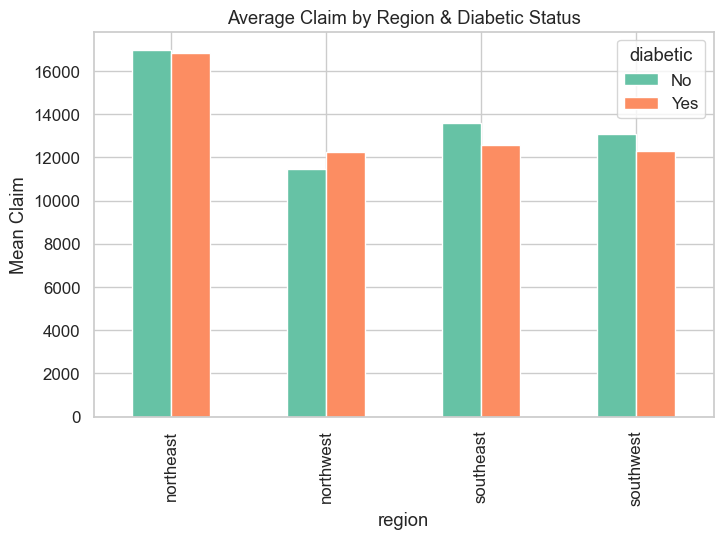

In [173]:
pivot_region_diabetic.plot(kind='bar', figsize=(8,5))
plt.title("Average Claim by Region & Diabetic Status")
plt.ylabel("Mean Claim")
plt.show()

In [174]:
pivot_table = pd.pivot_table(df, values='claim', index='region', columns='smoker', aggfunc='mean')
pivot_table

smoker,No,Yes
region,,
northeast,11666.112195,29673.536269
northwest,8076.203415,30192.002759
southeast,7444.144872,34844.997253
southwest,8294.754102,32269.064138


In [175]:
pivot_table = pd.pivot_table(df, values='claim', index='children', columns='diabetic', aggfunc='mean')
pivot_table

diabetic,No,Yes
children,,
0,12967.395398,11985.289857
1,12730.455810,12732.055724
2,15567.767583,14579.360417
3,13807.612892,17091.258649
4,14106.630000,13573.352500
5,8519.043636,9205.594286


In [176]:
df[numeric_cols].corr()

,age,bmi,bloodpressure,children,claim
age,1.000000,-0.042152,-0.060322,-0.026208,-0.028636
bmi,-0.042152,1.000000,0.144977,0.013719,0.199945
bloodpressure,-0.060322,0.144977,1.000000,-0.034356,0.531263
children,-0.026208,0.013719,-0.034356,1.000000,0.064149
claim,-0.028636,0.199945,0.531263,0.064149,1.000000


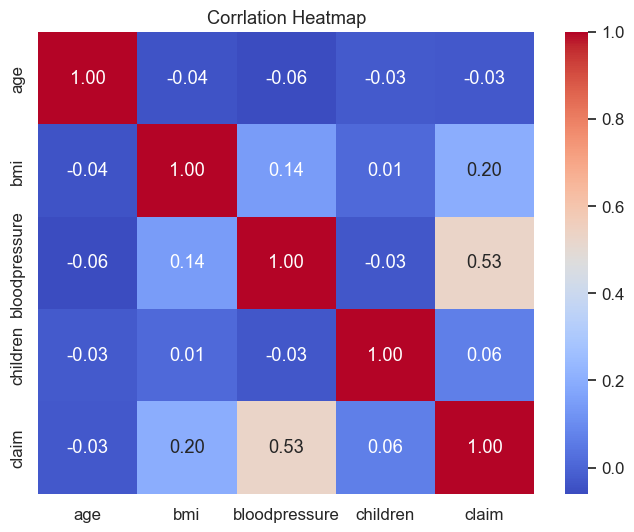

In [177]:
plt.figure(figsize=(8,6))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Corrlation Heatmap")
plt.show()

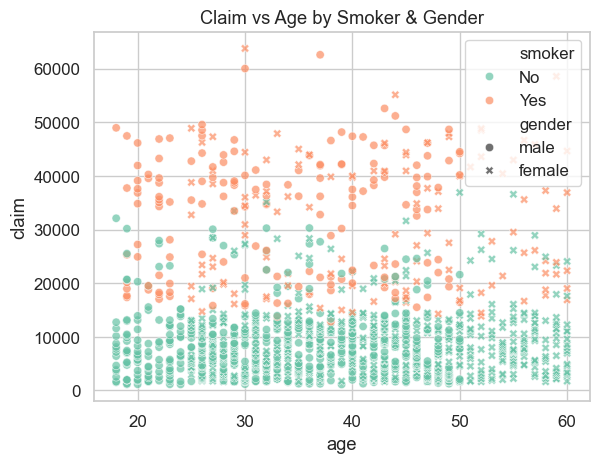

In [178]:
sns.scatterplot(data=df, x='age', y='claim', hue='smoker', style='gender', alpha=0.7)
plt.title("Claim vs Age by Smoker & Gender")
plt.show()

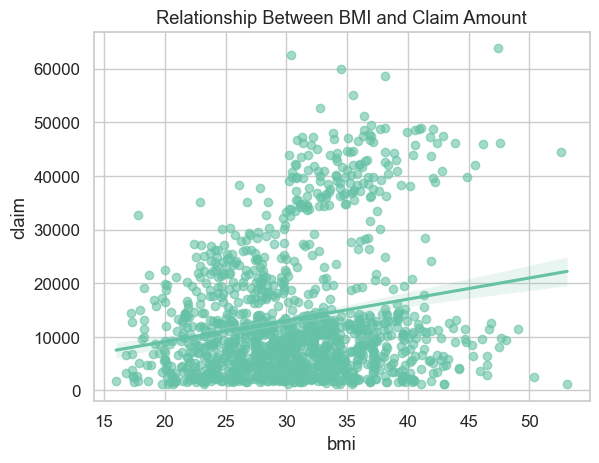

In [179]:
sns.regplot(data=df, x='bmi', y='claim', scatter_kws={'alpha':0.6})
plt.title('Relationship Between BMI and Claim Amount')
plt.show()

/var/folders/gx/3hdn2trj407cfml5pfq8jd9m0000gn/T/ipykernel_59834/3235470684.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='children', y='claim', palette='Set2')


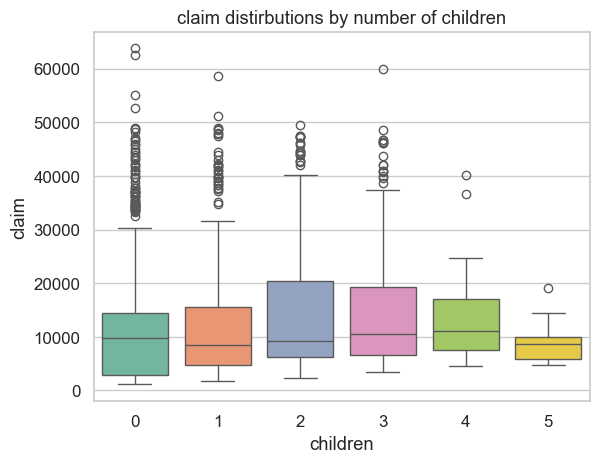

In [180]:
sns.boxplot(data=df, x='children', y='claim', palette='Set2')
plt.title('claim distirbutions by number of children')
plt.show()

In [181]:
df['age_group']=pd.cut(df['age'], bins=[14,24,44,60], labels=['Youth', 'Young Adults', 'Middle Age'])
df

,Id,age,gender,bmi,bloodpressure,diabetic,children,smoker,region,claim,age_group
0,1,39.000000,male,23.200000,91,Yes,0,No,southeast,1121.870000,Young Adults
1,2,24.000000,male,30.100000,87,No,0,No,southeast,1131.510000,Youth
7,8,19.000000,male,41.100000,100,No,0,No,northwest,1146.800000,Youth
8,9,20.000000,male,43.000000,86,No,0,No,northwest,1149.400000,Youth
9,10,30.000000,male,53.100000,97,No,0,No,northwest,1163.460000,Young Adults
...,...,...,...,...,...,...,...,...,...,...,...
1335,1336,44.000000,female,35.500000,88,Yes,0,Yes,northwest,55135.400000,Young Adults
1336,1337,59.000000,female,38.100000,120,No,1,Yes,northeast,58571.070000,Middle Age
1337,1338,30.000000,male,34.500000,91,Yes,3,Yes,northwest,60021.400000,Young Adults
1338,1339,37.000000,male,30.400000,106,No,0,Yes,southeast,62592.870000,Young Adults


In [182]:
df['age_group'].value_counts()

age_group
Young Adults    752
Middle Age      423
Youth           157
Name: count, dtype: int64

/var/folders/gx/3hdn2trj407cfml5pfq8jd9m0000gn/T/ipykernel_59834/1557167167.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='age_group', y='claim', estimator='mean', errorbar='sd', palette='Set2')


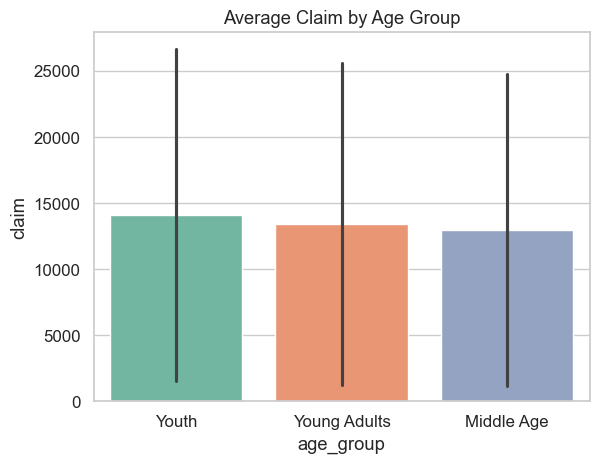

In [183]:
sns.barplot(data=df, x='age_group', y='claim', estimator='mean', errorbar='sd', palette='Set2')
plt.title("Average Claim by Age Group")
plt.show()

In [184]:
df['bmi_category'] = pd.cut(df['bmi'], bins=[0,18.5,24.9,29.9,100], labels=['underweight', 'normal', 'overweight', 'obese'])
df['bmi_category'].value_counts()

bmi_category
obese          702
overweight     387
normal         222
underweight     21
Name: count, dtype: int64

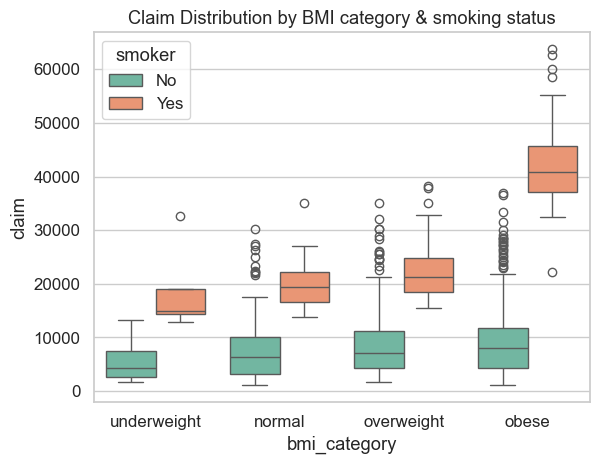

In [185]:
sns.boxplot(data=df, x='bmi_category', y='claim', hue='smoker')
plt.title("Claim Distribution by BMI category & smoking status")
plt.show()

In [186]:
region_stats = df.groupby("region").agg(
    smoker_rate = ('smoker', lambda x: (x=='Yes').mean() * 100),
    mean_claim = ('claim', 'mean')
).reset_index()

In [187]:
region_stats

,region,smoker_rate,mean_claim
0,northeast,29.004329,16889.044719
1,northwest,16.811594,11794.221855
2,southeast,20.588235,13085.496833
3,southwest,18.471338,12723.129841


/var/folders/gx/3hdn2trj407cfml5pfq8jd9m0000gn/T/ipykernel_59834/320798272.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data = region_stats, x='region', y='smoker_rate', ax=ax1, alpha=0.6, palette='Set2')


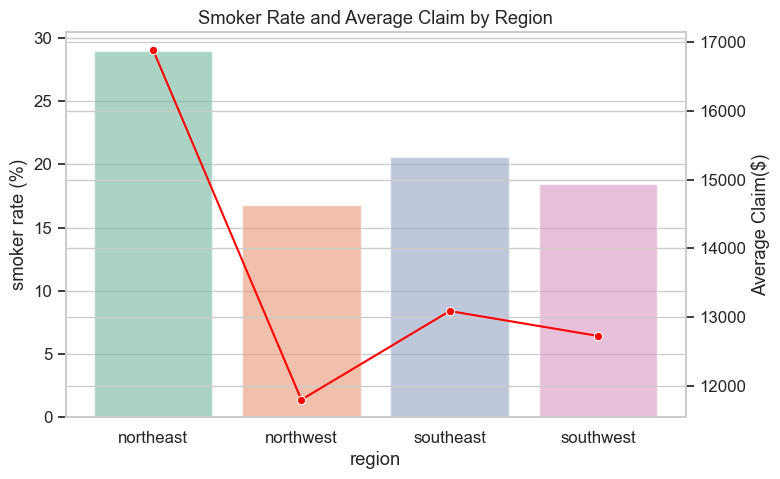

In [188]:
fig, ax1 = plt.subplots(figsize=(8,5))
sns.barplot(data = region_stats, x='region', y='smoker_rate', ax=ax1, alpha=0.6, palette='Set2')
ax2 = ax1.twinx()
sns.lineplot(data=region_stats, x='region', y='mean_claim', ax=ax2, color='red', marker='o')

ax1.set_ylabel('smoker rate (%)')
ax2.set_ylabel('Average Claim($)')
plt.title('Smoker Rate and Average Claim by Region')
plt.show()

In [189]:
from sklearn.model_selection import train_test_split

In [190]:
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error
from matplotlib.pyplot import subplots
from pygam import GammaGAM, s, f

import sklearn.model_selection as skm
from ISLP.models import ModelSpec as MS

from sklearn.metrics import mean_absolute_error, mean_squared_error

In [191]:
def eval_metrics(y_true, y_pred):
    return {
        "MAE": float(mean_absolute_error(y_true, y_pred)),
        "RMSE": float(np.sqrt(mean_squared_error(y_true, y_pred)))
    }

results_dict = {}

In [192]:
idx = np.arange(len(df))
train_idx, test_idx = skm.train_test_split(idx, test_size=0.3, random_state=0)

y = df["claim"].values
y_train, y_test = y[train_idx], y[test_idx]

In [193]:
terms = df.columns.drop(['claim', 'Id', 'age', 'bmi'])

cat_cols = ['gender', 'smoker', 'region', 'age_group', 'bmi_category', 'diabetic']
for c in cat_cols:
    df[c] = df[c].astype('category')
    df[c] = df[c].cat.as_unordered()

X_ols_all = MS(terms, intercept=True).fit_transform(df)   
X_ols_train = X_ols_all.iloc[train_idx]
X_ols_test  = X_ols_all.iloc[test_idx]

ols_model = sm.OLS(y_train, X_ols_train)
ols_res = ols_model.fit()
y_pred_ols = ols_res.predict(X_ols_test)

print(summarize(ols_res))

results_dict["Linear Regression (OLS)"] = eval_metrics(y_test, y_pred_ols)

                                  coef     std err         t    P>|t|
intercept                -16820.000000 2917.523000 -5.764000 0.000000
gender[male]               -210.332700  474.009000 -0.444000 0.657000
bloodpressure               226.032900   21.418000 10.553000 0.000000
diabetic[Yes]              -416.367200  433.263000 -0.961000 0.337000
children                    636.601600  176.320000  3.610000 0.000000
smoker[Yes]               21490.000000  608.284000 35.336000 0.000000
region[northwest]         -1531.970000  674.889000 -2.270000 0.023000
region[southeast]         -2131.266500  639.566000 -3.332000 0.001000
region[southwest]         -1345.416400  696.712000 -1.931000 0.054000
age_group[Young Adults]    1304.637300  728.212000  1.792000 0.074000
age_group[Middle Age]      1238.796500  811.980000  1.526000 0.127000
bmi_category[normal]       1730.483800 1974.912000  0.876000 0.381000
bmi_category[overweight]   2786.298500 1944.492000  1.433000 0.152000
bmi_category[obese] 

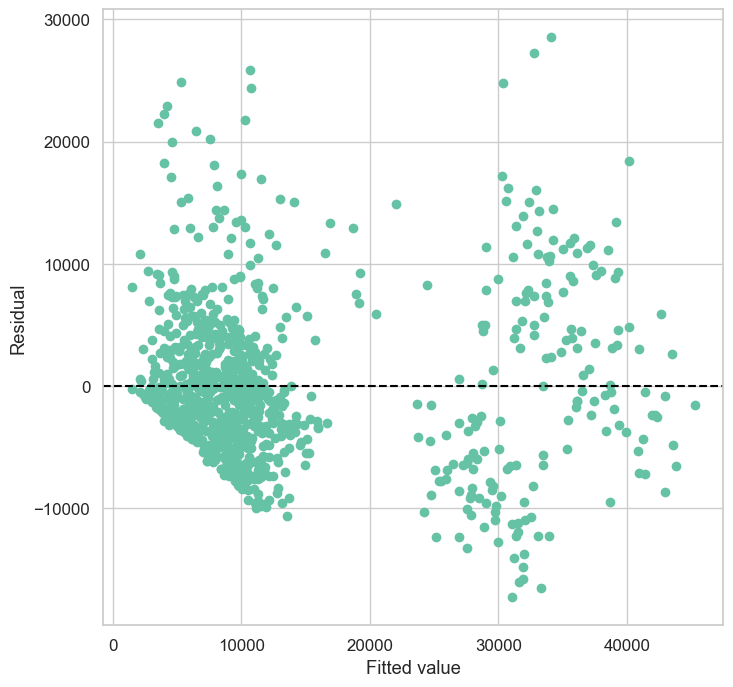

In [194]:
ax = subplots(figsize=(8,8))[1]
ax.scatter(ols_res.fittedvalues, ols_res.resid)  
ax.set_xlabel('Fitted value')
ax.set_ylabel('Residual')
ax.axhline(0, c='k', ls='--')

In [195]:
Xgam_all = np.column_stack([
    df["bloodpressure"].values,
    df["children"].values,
    df["gender"].cat.codes.values,
    df["diabetic"].cat.codes.values,
    df["smoker"].cat.codes.values,
    df["region"].cat.codes.values,
    df["age_group"].cat.codes.values,
    df["bmi_category"].cat.codes.values
])

In [196]:
Xgam_train = Xgam_all[train_idx]
Xgam_test  = Xgam_all[test_idx]

In [197]:
gam = GammaGAM(
    s(0, n_splines=10) +
    s(1, n_splines=10) +
    f(2) + f(3) + f(4) + f(5) + f(6) + f(7)
).fit(Xgam_train, y_train)
print(gam.summary())

GammaGAM                                                                                                  
=============================================== ==========================================================
Distribution:                         GammaDist Effective DoF:                                     22.3963
Link Function:                          LogLink Log Likelihood:                                 -9436.8574
Number of Samples:                          932 AIC:                                            18920.5074
                                                AICc:                                           18921.7652
                                                GCV:                                                 0.388
                                                Scale:                                              0.6308
                                                Pseudo R-Squared:                                   0.5408
Feature Function                  Lam

/var/folders/gx/3hdn2trj407cfml5pfq8jd9m0000gn/T/ipykernel_59834/2258950504.py:6: UserWarning: KNOWN BUG: p-values computed in this summary are likely much smaller than they should be. 
 
Please do not make inferences based on these values! 

Collaborate on a solution, and stay up to date at: 
github.com/dswah/pyGAM/issues/163 

  print(gam.summary())


In [198]:
y_pred_gam = gam.predict(Xgam_test)

results_dict["Gamma GAM (pyGAM)"] = eval_metrics(y_test, y_pred_gam)

In [199]:
import numpy as np
import pandas as pd
from matplotlib.pyplot import subplots
import sklearn.model_selection as skm
from ISLP.models import ModelSpec as MS
from sklearn.ensemble import RandomForestRegressor as RF

model = MS(df.columns.drop(['claim', 'Id', 'age', 'bmi']), intercept=False)
D = model.fit_transform(df)
feature_names = list(D.columns)
X = np.asarray(D)

X_train, X_test = X[train_idx], X[test_idx]

Bagging MSE: 31310225.762094725


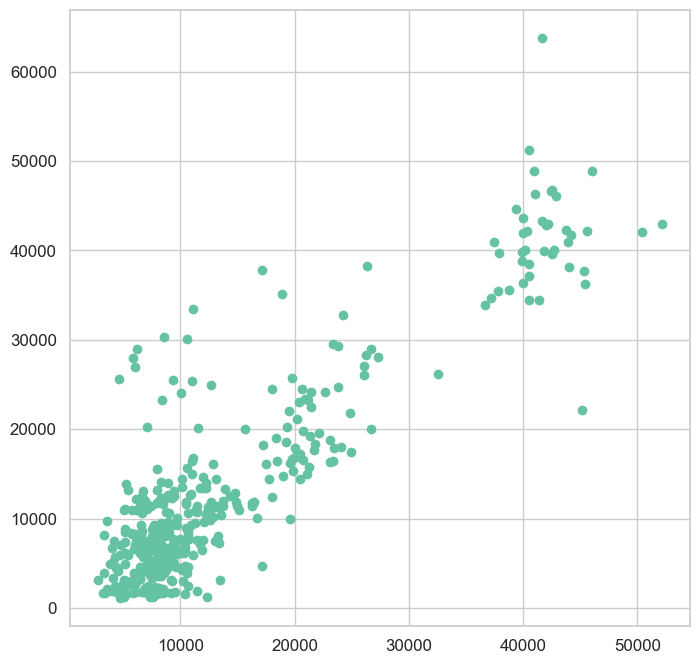

In [200]:
bag_boston = RF(max_features=X_train.shape[1], random_state=0)
bag_boston.fit(X_train, y_train)

y_hat_bag = bag_boston.predict(X_test)
1
ax = subplots(figsize=(8, 8))[1]
ax.scatter(y_hat_bag, y_test)

print("Bagging MSE:", np.mean((y_test - y_hat_bag)**2))

results_dict["Bagging"] = eval_metrics(y_test, y_hat_bag)

In [201]:
RF_df = RF(max_features=4, random_state=0).fit(X_train, y_train)
y_hat_RF = RF_df.predict(X_test)

print("Random Forest MSE:", np.mean((y_test - y_hat_RF)**2))
results_dict["Random Forest"] = eval_metrics(y_test, y_hat_RF)

feature_imp = pd.DataFrame(
    {'importance': RF_df.feature_importances_},
    index=feature_names
).sort_values(by='importance', ascending=False)

feature_imp

Random Forest MSE: 31044341.64083661


,importance
smoker[Yes],0.516534
bloodpressure,0.262936
bmi_category[obese],0.062218
children,0.037925
bmi_category[normal],0.017742
bmi_category[overweight],0.016934
gender[male],0.015891
diabetic[Yes],0.015109
region[southeast],0.012576
age_group[Young Adults],0.011670


In [202]:
from xgboost import XGBRegressor

model = MS(df.columns.drop(['claim', 'Id', 'age', 'bmi']), intercept=False)
D = model.fit_transform(df)
feature_names = list(D.columns)
X = np.asarray(D)

X_train, X_test = X[train_idx], X[test_idx]

xgb = XGBRegressor(
    n_estimators=3000,
    learning_rate=0.01,
    max_depth=3,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.0,
    reg_lambda=1.0,
    objective="reg:squarederror",
    random_state=0,
    n_jobs=-1,
)

xgb.fit(X_train, y_train)
y_hat_xgb = xgb.predict(X_test)
print("XGBoost MSE:", np.mean((y_test - y_hat_xgb)**2))
results_dict["XGBoost"] = eval_metrics(y_test, y_hat_xgb)

XGBoost MSE: 30339613.230972763


In [203]:
results_df = pd.DataFrame(results_dict).T.sort_values("RMSE")
results_df

,MAE,RMSE
XGBoost,3889.091467,5508.140633
Random Forest,3947.737594,5571.744937
Bagging,4014.835540,5595.554107
Linear Regression (OLS),5015.581800,6633.237627
Gamma GAM (pyGAM),4709.963626,6640.357906


In [204]:
models = {
    "Linear Regression (OLS)": ols_res,
    "Gamma GAM (pyGAM)": gam,
    "Bagging": bag_boston,
    "Random Forest": RF_df,
    "XGBoost": xgb
}

In [205]:
best_model_name = results_df.index[0]
best_model = models[best_model_name]

import joblib

if best_model_name == "Linear Regression (OLS)":
    terms = df.columns.drop(['claim', 'Id', 'age', 'bmi'])
    spec = MS(terms, intercept=True)                 
    X_all = spec.fit_transform(df)
    feature_order = list(X_all.columns)

else:
    terms = df.columns.drop(['claim', 'Id', 'age', 'bmi'])
    spec = MS(terms, intercept=False)                
    X_all = spec.fit_transform(df)
    feature_order = list(X_all.columns)

joblib.dump(spec, "model_spec.pkl")
joblib.dump(feature_order, "feature_order.pkl")
joblib.dump(best_model, "best_model.pkl")
joblib.dump(best_model_name, "best_model_name.pkl")
print("Saved model + matching spec + feature order")

Saved model + matching spec + feature order
